In [1]:
import pandas as pd
import numpy as np
import pyodbc
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("Librerías de análisis y Machine Learning cargadas correctamente.")

Librerías de análisis y Machine Learning cargadas correctamente.


In [2]:
servidor = 'DESKTOP-NDQC05N'
base_datos = 'DonaldV2'
cadena_conexion = f'DRIVER={{SQL Server}};SERVER={servidor};DATABASE={base_datos};Trusted_Connection=yes;'

print(f"Conectando a {base_datos}...")
conn = pyodbc.connect(cadena_conexion)

query_rfm = """
SELECT 
    c.CodigoCliente,
    CONCAT(ISNULL(sn.PrimerNombre, ''), ' ', 
    ISNULL(sn.SegundoNombre, ''), ' ', 
    ISNULL(sn.PrimerApellido, ''), ' ', 
    ISNULL(sn.SegundoApellido, '')) AS NombreCompleto,
    DATEDIFF(DAY, MAX(ot.FechaOrden), '2026-06-05') AS Recencia,
    COUNT(DISTINCT ot.NumeroOrden) AS Frecuencia,
    SUM(ISNULL(dmo.Unidades * mo.Precio, 0) + ISNULL(dm.Unidades * dm.PrecioVenta, 0)) AS ValorMonetario
FROM [dbo].[Cliente] c
INNER JOIN [dbo].[SocioNegocio] sn ON c.CodigoSocio = sn.CodigoSocio
INNER JOIN [dbo].[Cita] ci ON c.CodigoCliente = ci.CodigoCliente
INNER JOIN [dbo].[OrdeDeTrabajo] ot ON ci.NumeroCita = ot.NumeroCita
LEFT JOIN [dbo].[DetalleManoDeObra] dmo ON ot.NumeroOrden = dmo.NumeroOrden
LEFT JOIN [dbo].[ManoObra] mo ON dmo.CodigoManoObra = mo.CodigoManoObra
LEFT JOIN [dbo].[DetalleMaterial] dm ON ot.NumeroOrden = dm.NumeroOrden
GROUP BY c.CodigoCliente, sn.PrimerNombre, sn.SegundoNombre, sn.PrimerApellido, sn.SegundoApellido
"""

df_rfm = pd.read_sql(query_rfm, conn)
conn.close()
print("Conexión cerrada de forma segura.")

df_rfm['ValorMonetario'] = df_rfm['ValorMonetario'].fillna(0)
df_rfm['NombreCompleto'] = df_rfm['NombreCompleto'].str.strip().replace('', 'Cliente Sin Nombre')

print(f"Total de clientes únicos extraídos: {len(df_rfm):,}")
df_rfm.head() # Muestra las primeras 5 filas con formato de tabla en el Notebook

Conectando a DonaldV2...


C:\Users\Christian Chamo\AppData\Local\Temp\ipykernel_6724\1408058525.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_rfm = pd.read_sql(query_rfm, conn)


Conexión cerrada de forma segura.
Total de clientes únicos extraídos: 383,037


,CodigoCliente,NombreCompleto,Recencia,Frecuencia,ValorMonetario
0,100506,Pablo Espiridi+¦n Revilla Batalla,284,7,169934.8180
1,369886,Gilberto Te+¦fila Ba+¦os Perell+¦,271,8,399599.7529
2,371091,Te+¦fila Gonzalo Sastre Esteban,415,6,231203.6999
3,58907,N/A,479,5,104320.1337
4,25661,Eduardo Salom+¦n Carnero Verd+¦,689,1,23747.2984


In [3]:
columnas_analisis = ['Recencia', 'Frecuencia', 'ValorMonetario']
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_rfm[columnas_analisis])

df_scaled_preview = pd.DataFrame(X_scaled, columns=columnas_analisis)
print("Variables normalizadas con StandardScaler:")
df_scaled_preview.head()

Variables normalizadas con StandardScaler:


,Recencia,Frecuencia,ValorMonetario
0,-0.854160,0.585171,0.108409
1,-0.917768,0.914183,2.266258
2,-0.213181,0.256160,0.684069
3,0.099968,-0.072852,-0.508083
4,1.127491,-1.388900,-1.265116


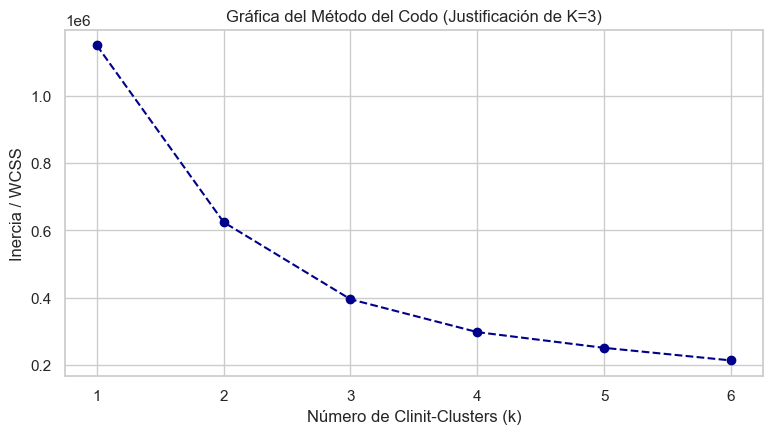

In [4]:
wcss = []
for i in range(1, 7):
    kmeans_prueba = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_prueba.fit(X_scaled)
    wcss.append(kmeans_prueba.inertia_)

plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 7), wcss, marker='o', linestyle='--', color='darkblue')
plt.title('Gráfica del Método del Codo (Justificación de K=3)')
plt.xlabel('Número de Clinit-Clusters (k)')
plt.ylabel('Inercia / WCSS')
plt.grid(True)
plt.show()

In [5]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df_rfm['Cluster'] = kmeans.fit_predict(X_scaled)

resumen_clusters = df_rfm.groupby('Cluster')[['Recencia', 'ValorMonetario']].mean()

cluster_vip = resumen_clusters['ValorMonetario'].idxmax()
cluster_riesgo = resumen_clusters['Recencia'].idxmax()
cluster_esporadico = [c for c in [0, 1, 2] if c not in [cluster_vip, cluster_riesgo]][0]

def evaluar_segmento(cluster_id):
    if cluster_id == cluster_vip:
        return "Clientes VIP (Alto Valor)"
    elif cluster_id == cluster_riesgo:
        return "Clientes en Riesgo de Abandono"
    else:
        return "Clientes Esporádicos (Ticket Medio)"

df_rfm['Categoria_Final'] = df_rfm['Cluster'].apply(evaluar_segmento)
print("Entrenamiento completado. Etiquetas asignadas con base en comportamiento estadístico.")

Entrenamiento completado. Etiquetas asignadas con base en comportamiento estadístico.


In [6]:
total_base = len(df_rfm)
distribucion = df_rfm['Categoria_Final'].value_counts()

print("INFORME EJECUTIVO DE DISTRIBUCIÓN DE CLIENTES:")
print("-" * 55)
for categoria, total in distribucion.items():
    pct = (total / total_base) * 100
    print(f"🔹 {categoria:<35} | Clientes: {total:<8,} | Porcentaje: {pct:.2f}%")
print("-" * 55)

ruta_csv = 'TallerDonald_Final.csv'
df_rfm.to_csv(ruta_csv, index=False, encoding='utf-8')
print(f"Guardado exitoso: El archivo '{ruta_csv}' está listo para alimentar el Dashboard.")

INFORME EJECUTIVO DE DISTRIBUCIÓN DE CLIENTES:
-------------------------------------------------------
🔹 Clientes Esporádicos (Ticket Medio) | Clientes: 204,300  | Porcentaje: 53.34%
🔹 Clientes VIP (Alto Valor)           | Clientes: 106,782  | Porcentaje: 27.88%
🔹 Clientes en Riesgo de Abandono      | Clientes: 71,955   | Porcentaje: 18.79%
-------------------------------------------------------
Guardado exitoso: El archivo 'TallerDonald_Final.csv' está listo para alimentar el Dashboard.
